# Recommendation Engine - Milestone 3

## Objective
This notebook implements a recommendation engine that:
1. Loads clustered student/customer data from Milestone 2
2. Performs cluster analysis to understand student segments
3. Maps each cluster to personalized recommendations
4. Generates recommendations for all students
5. Visualizes recommendation distribution
6. Exports results for further analysis


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from pathlib import Path

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Create visualizations directory if it doesn't exist
os.makedirs('visualizations', exist_ok=True)

print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Data Loading


In [2]:
# Try to load milestone2_with_clusters.csv, or create demo data if missing
data_file = 'milestone2_with_clusters.csv'

if os.path.exists(data_file):
    print(f"Loading data from {data_file}...")
    df = pd.read_csv(data_file)
    print(f"✓ Loaded {len(df)} records from {data_file}")
    print(f"\nColumns: {df.columns.tolist()}")
    print(f"\nFirst few rows:")
    display(df.head())
else:
    print(f"⚠ {data_file} not found. Creating demo dataset...")
    
    # Create demo dataframe with student/customer features and clusters
    np.random.seed(42)
    n_samples = 200
    
    demo_data = {
        'StudentID': [f'STU{i:04d}' for i in range(1, n_samples + 1)],
        'Revenue_sum': np.random.lognormal(mean=5, sigma=1.5, size=n_samples),
        'InvoiceNo_nunique': np.random.randint(5, 150, size=n_samples),
        'avg_order_value': np.random.uniform(20, 500, size=n_samples),
        'days_active': np.random.randint(10, 365, size=n_samples),
        'Quantity_sum': np.random.randint(50, 2000, size=n_samples),
        'ClusterID': np.random.choice([0, 1, 2], size=n_samples, p=[0.4, 0.4, 0.2])
    }
    
    df = pd.DataFrame(demo_data)
    print(f"✓ Created demo dataset with {len(df)} records")
    print(f"\nColumns: {df.columns.tolist()}")
    print(f"\nFirst few rows:")
    display(df.head())


⚠ milestone2_with_clusters.csv not found. Creating demo dataset...
✓ Created demo dataset with 200 records

Columns: ['StudentID', 'Revenue_sum', 'InvoiceNo_nunique', 'avg_order_value', 'days_active', 'Quantity_sum', 'ClusterID']

First few rows:


,StudentID,Revenue_sum,InvoiceNo_nunique,avg_order_value,days_active,Quantity_sum,ClusterID
0,STU0001,312.645897,134,90.370314,128,373,0
1,STU0002,120.614987,21,266.396561,37,893,0
2,STU0003,392.106234,108,131.949475,211,1758,1
3,STU0004,1457.597461,141,299.026600,48,179,0
4,STU0005,104.456419,47,434.306491,282,1484,0


## 2. Cluster Analysis


In [3]:
# Ensure ClusterID column exists (check for common cluster column names)
cluster_col = None
for col in ['ClusterID', 'kmeans_cluster', 'dbscan_cluster', 'cluster']:
    if col in df.columns:
        cluster_col = col
        break

if cluster_col is None:
    print("⚠ No cluster column found. Creating ClusterID from kmeans_cluster or defaulting to 0...")
    if 'kmeans_cluster' in df.columns:
        df['ClusterID'] = df['kmeans_cluster']
        cluster_col = 'ClusterID'
    else:
        df['ClusterID'] = 0
        cluster_col = 'ClusterID'
else:
    if cluster_col != 'ClusterID':
        df['ClusterID'] = df[cluster_col]
        cluster_col = 'ClusterID'

print(f"Using cluster column: {cluster_col}")
print(f"\n{'='*60}")
print("CLUSTER DISTRIBUTION")
print(f"{'='*60}")
cluster_counts = df[cluster_col].value_counts().sort_index()
print(cluster_counts)
print(f"\nTotal students: {len(df)}")


Using cluster column: ClusterID

CLUSTER DISTRIBUTION
ClusterID
0    86
1    74
2    40
Name: count, dtype: int64

Total students: 200


In [4]:
# Numeric summaries by cluster
print(f"\n{'='*60}")
print("NUMERIC SUMMARIES BY CLUSTER")
print(f"{'='*60}")

# Identify numeric columns (excluding ID columns)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'StudentID' in numeric_cols:
    numeric_cols.remove('StudentID')
if 'CustomerID' in numeric_cols:
    numeric_cols.remove('CustomerID')

if numeric_cols:
    cluster_summary = df.groupby(cluster_col)[numeric_cols].agg(['mean', 'std', 'min', 'max'])
    display(cluster_summary)
else:
    print("No numeric columns found for summary statistics.")



NUMERIC SUMMARIES BY CLUSTER


Revenue_sum                                      InvoiceNo_nunique  \
                 mean          std        min          max              mean   
ClusterID                                                                      
0          337.461378   746.191031   7.528130  5972.155334         84.220930   
1          513.045549  1120.979324  10.542764  8780.193718         79.391892   
2          259.035665   620.545027   2.916494  3966.674792         77.500000   

                              avg_order_value              ... days_active  \
                 std min  max            mean         std  ...         min   
ClusterID                                                  ...               
0          44.510779  12  149      242.336642  126.283958  ...          10   
1          41.568171   5  148      269.095430  149.609852  ...          13   
2          44.847319   9  148      256.403091  123.535114  ...          14   

               Quantity_sum                        ClusterID               
           max         mean         std  min   max      mean  std min max  
ClusterID                                                                  
0          362  1043.883721  580.292308   60  1984       0.0  0.0   0   0  
1          362   985.905405  531.436208   67  1970       1.0  0.0   1   1  
2          359  1066.200000  575.905895  104  1978       2.0  0.0   2   2  

[3 rows x 24 columns]

## 3. Cluster → Recommendation Mapping

### Mapping Rationale
Based on cluster characteristics, we map each cluster to personalized recommendations:
- **High-engagement clusters**: Focus on advanced courses and premium features
- **Medium-engagement clusters**: Recommend intermediate courses and engagement boosters
- **Low-engagement clusters**: Suggest foundational courses and re-engagement strategies


In [5]:
# Define cluster to recommendation mapping
# This is a student-domain example mapping ClusterID to recommendations

CLUSTER_RECOMMENDATION_MAPPING = {
    0: {
        'Recommendation': 'Foundational Learning Path',
        'Recommendation_Details': {
            'primary_focus': 'Build strong fundamentals',
            'suggested_courses': ['Introduction to Core Concepts', 'Basic Skills Workshop'],
            'engagement_strategy': 'Weekly check-ins and progress tracking',
            'resources': 'Starter course bundle with mentor support',
            'timeline': '3-6 months'
        }
    },
    1: {
        'Recommendation': 'Intermediate Skill Development',
        'Recommendation_Details': {
            'primary_focus': 'Expand knowledge and apply skills',
            'suggested_courses': ['Advanced Techniques', 'Project-Based Learning'],
            'engagement_strategy': 'Bi-weekly reviews and peer collaboration',
            'resources': 'Intermediate course package with community access',
            'timeline': '4-8 months'
        }
    },
    2: {
        'Recommendation': 'Advanced Mastery Program',
        'Recommendation_Details': {
            'primary_focus': 'Achieve expertise and specialization',
            'suggested_courses': ['Expert-Level Certification', 'Specialization Track'],
            'engagement_strategy': 'Monthly mentorship and leadership opportunities',
            'resources': 'Premium course suite with exclusive content',
            'timeline': '6-12 months'
        }
    }
}

# Handle additional clusters that might exist
max_cluster = df[cluster_col].max()
for cluster_id in range(3, int(max_cluster) + 1):
    if cluster_id not in CLUSTER_RECOMMENDATION_MAPPING:
        CLUSTER_RECOMMENDATION_MAPPING[cluster_id] = {
            'Recommendation': f'Customized Learning Path - Cluster {cluster_id}',
            'Recommendation_Details': {
                'primary_focus': 'Personalized learning approach',
                'suggested_courses': ['Tailored Course Selection'],
                'engagement_strategy': 'Individualized support plan',
                'resources': 'Custom course package',
                'timeline': 'Flexible'
            }
        }

print("Cluster → Recommendation Mapping:")
print(f"{'='*60}")
for cluster_id, mapping in sorted(CLUSTER_RECOMMENDATION_MAPPING.items()):
    print(f"\nCluster {cluster_id}:")
    print(f"  Recommendation: {mapping['Recommendation']}")
    print(f"  Details: {json.dumps(mapping['Recommendation_Details'], indent=4)}")


Cluster → Recommendation Mapping:

Cluster 0:
  Recommendation: Foundational Learning Path
  Details: {
    "primary_focus": "Build strong fundamentals",
    "suggested_courses": [
        "Introduction to Core Concepts",
        "Basic Skills Workshop"
    ],
    "engagement_strategy": "Weekly check-ins and progress tracking",
    "resources": "Starter course bundle with mentor support",
    "timeline": "3-6 months"
}

Cluster 1:
  Recommendation: Intermediate Skill Development
  Details: {
    "primary_focus": "Expand knowledge and apply skills",
    "suggested_courses": [
        "Advanced Techniques",
        "Project-Based Learning"
    ],
    "engagement_strategy": "Bi-weekly reviews and peer collaboration",
    "resources": "Intermediate course package with community access",
    "timeline": "4-8 months"
}

Cluster 2:
  Recommendation: Advanced Mastery Program
  Details: {
    "primary_focus": "Achieve expertise and specialization",
    "suggested_courses": [
        "Expert-Lev

## 4. Recommendation Generation Function


In [6]:
def generate_recommendation(row, mapping):
    """
    Generate recommendation for a student row based on cluster mapping.
    
    Parameters:
    -----------
    row : pandas.Series
        A row from the dataframe containing at least 'ClusterID'
    mapping : dict
        Dictionary mapping ClusterID to recommendation details
        
    Returns:
    --------
    tuple : (recommendation_string, recommendation_details_string)
        CSV-friendly strings for Recommendation and Recommendation_Details columns
    """
    cluster_id = row.get('ClusterID', 0)
    
    # Get recommendation for this cluster, default to cluster 0 if not found
    if cluster_id not in mapping:
        cluster_id = 0
    
    rec_info = mapping[cluster_id]
    recommendation = rec_info['Recommendation']
    
    # Convert details dict to CSV-friendly string (JSON format)
    details_dict = rec_info['Recommendation_Details']
    recommendation_details = json.dumps(details_dict)
    
    return recommendation, recommendation_details

# Test the function
print("Testing generate_recommendation function:")
print(f"{'='*60}")
test_row = df.iloc[0]
rec, details = generate_recommendation(test_row, CLUSTER_RECOMMENDATION_MAPPING)
print(f"Test row ClusterID: {test_row.get('ClusterID', 'N/A')}")
print(f"Generated Recommendation: {rec}")
print(f"Generated Details: {details}")


Testing generate_recommendation function:
Test row ClusterID: 0
Generated Recommendation: Foundational Learning Path
Generated Details: {"primary_focus": "Build strong fundamentals", "suggested_courses": ["Introduction to Core Concepts", "Basic Skills Workshop"], "engagement_strategy": "Weekly check-ins and progress tracking", "resources": "Starter course bundle with mentor support", "timeline": "3-6 months"}


## 5. Apply Recommendations to Dataset


In [7]:
# Apply recommendation function row-wise
print("Generating recommendations for all students...")
df[['Recommendation', 'Recommendation_Details']] = df.apply(
    lambda row: pd.Series(generate_recommendation(row, CLUSTER_RECOMMENDATION_MAPPING)),
    axis=1
)

print(f"✓ Recommendations generated for {len(df)} students")
print(f"\nRecommendation distribution:")
print(df['Recommendation'].value_counts())
print(f"\nFirst few rows with recommendations:")
display(df[['StudentID' if 'StudentID' in df.columns else df.columns[0], 
            cluster_col, 'Recommendation', 'Recommendation_Details']].head())


Generating recommendations for all students...
✓ Recommendations generated for 200 students

Recommendation distribution:
Recommendation
Foundational Learning Path        86
Intermediate Skill Development    74
Advanced Mastery Program          40
Name: count, dtype: int64

First few rows with recommendations:


,StudentID,ClusterID,Recommendation,Recommendation_Details
0,STU0001,0,Foundational Learning Path,"{""primary_focus"": ""Build strong fundamentals"",..."
1,STU0002,0,Foundational Learning Path,"{""primary_focus"": ""Build strong fundamentals"",..."
2,STU0003,1,Intermediate Skill Development,"{""primary_focus"": ""Expand knowledge and apply ..."
3,STU0004,0,Foundational Learning Path,"{""primary_focus"": ""Build strong fundamentals"",..."
4,STU0005,0,Foundational Learning Path,"{""primary_focus"": ""Build strong fundamentals"",..."


In [8]:
# Save augmented CSV
output_file = 'milestone3_with_recommendations.csv'
df.to_csv(output_file, index=False)
print(f"✓ Saved augmented dataset to {output_file}")
print(f"  Total records: {len(df)}")
print(f"  Total columns: {len(df.columns)}")


✓ Saved augmented dataset to milestone3_with_recommendations.csv
  Total records: 200
  Total columns: 9


## 6. Visualization: Recommendation Distribution


C:\Users\tarun\AppData\Local\Temp\ipykernel_11388\2889543073.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, y='Recommendation', order=rec_counts.index, palette=colors)


✓ Saved visualization to visualizations/recommendation_countplot.png


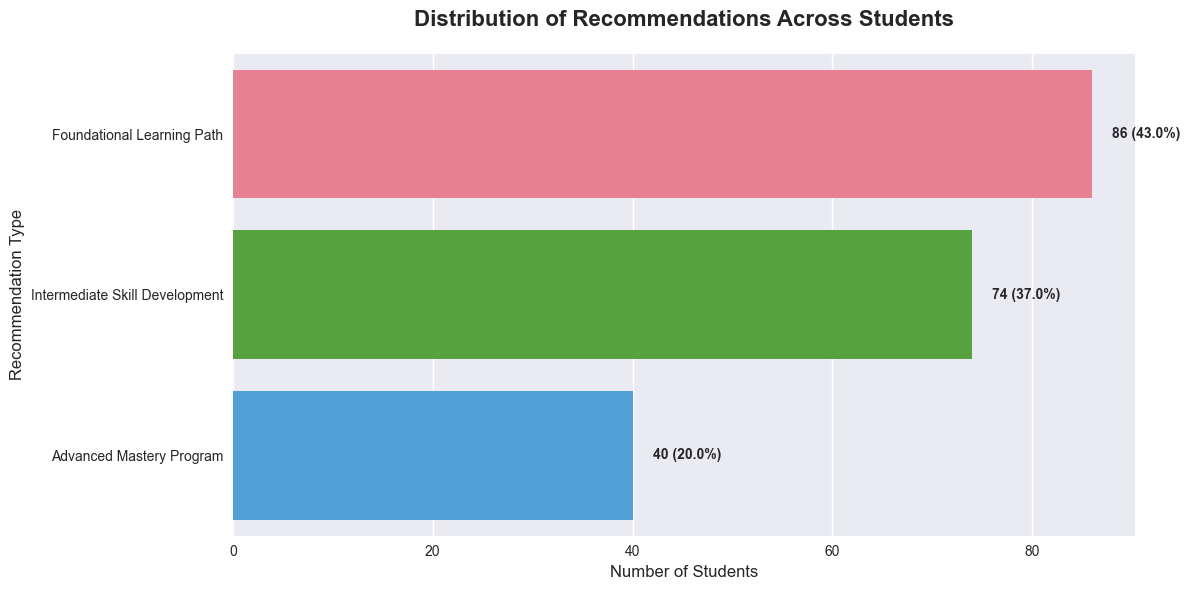

In [9]:
# Create countplot of recommendations
plt.figure(figsize=(12, 6))
rec_counts = df['Recommendation'].value_counts()
colors = sns.color_palette("husl", len(rec_counts))

ax = sns.countplot(data=df, y='Recommendation', order=rec_counts.index, palette=colors)
plt.title('Distribution of Recommendations Across Students', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Students', fontsize=12)
plt.ylabel('Recommendation Type', fontsize=12)

# Add count labels on bars
for i, (idx, val) in enumerate(rec_counts.items()):
    ax.text(val + len(df) * 0.01, i, f'{val} ({val/len(df)*100:.1f}%)', 
            va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('visualizations/recommendation_countplot.png', dpi=300, bbox_inches='tight')
print("✓ Saved visualization to visualizations/recommendation_countplot.png")
plt.show()


## 7. Observations and Insights


In [10]:
# Cross-tabulation: Cluster vs Recommendation
print("Cluster → Recommendation Cross-tabulation:")
print(f"{'='*60}")
crosstab = pd.crosstab(df[cluster_col], df['Recommendation'], margins=True)
display(crosstab)

# Summary statistics
print(f"\n{'='*60}")
print("Summary Statistics:")
print(f"{'='*60}")
print(f"Total students analyzed: {len(df)}")
print(f"Number of clusters: {df[cluster_col].nunique()}")
print(f"Number of unique recommendations: {df['Recommendation'].nunique()}")
print(f"\nRecommendation breakdown:")
for rec, count in df['Recommendation'].value_counts().items():
    print(f"  {rec}: {count} students ({count/len(df)*100:.1f}%)")


Cluster → Recommendation Cross-tabulation:


Recommendation,Advanced Mastery Program,Foundational Learning Path,Intermediate Skill Development,All
ClusterID,,,,
0,0,86,0,86
1,0,0,74,74
2,40,0,0,40
All,40,86,74,200



Summary Statistics:
Total students analyzed: 200
Number of clusters: 3
Number of unique recommendations: 3

Recommendation breakdown:
  Foundational Learning Path: 86 students (43.0%)
  Intermediate Skill Development: 74 students (37.0%)
  Advanced Mastery Program: 40 students (20.0%)
